# 03 — Hidden Markov Model
Fit a Gaussian HMM on the standardised 4-feature matrix. Select the number of states by BIC. Decode via Viterbi and compare with heuristic labels.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
from pathlib import Path
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')  # suppress convergence warnings during grid search

LABELLED_PATH = Path('../data/hourly_features_labelled.parquet')
SCALER_PATH   = Path('../data/scaler_params.pkl')
FEATURE_COLS  = ['log_return', 'swap_count', 'total_fees_usd', 'realised_vol']
N_RESTARTS    = 10
RANDOM_SEED   = 42

## 1. Load & standardise

In [9]:
df = pd.read_parquet(LABELLED_PATH)

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

X_raw = df[FEATURE_COLS].values.astype(float)
X     = (X_raw - scaler['means'].values) / scaler['stds'].values

print(f'Observation matrix shape: {X.shape}')
print(f'Any NaN: {np.isnan(X).any()}')

Observation matrix shape: (42301, 4)
Any NaN: False


## 2. Fit HMMs for n ∈ {2, 3, 4} and select by BIC
$$\text{BIC} = -2\ln\hat{L} + k\ln T$$
where $k$ = number of free parameters, $T$ = number of observations.

In [10]:
def count_free_params(model):
    """Count free parameters for a diagonal GaussianHMM."""
    n = model.n_components
    d = model.n_features
    # transmat: n*(n-1), startprob: n-1, means: n*d, covars (diag): n*d
    return n * (n - 1) + (n - 1) + n * d + n * d

results = {}
T = len(X)

for n in [2, 3, 4]:
    best_score = -np.inf
    best_model = None
    for seed in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=n,
            covariance_type='diag',
            n_iter=200,
            tol=1e-4,
            random_state=RANDOM_SEED + seed
        )
        try:
            model.fit(X)
            score = model.score(X)
            if score > best_score:
                best_score = score
                best_model = model
        except Exception:
            continue

    k   = count_free_params(best_model)
    bic = -2 * best_score * T + k * np.log(T)   # score() returns mean log-likelihood
    results[n] = {'model': best_model, 'log_likelihood': best_score * T, 'bic': bic, 'k': k}
    print(f'n={n}  log-L={best_score*T:,.1f}  k={k}  BIC={bic:,.1f}')

n=2  log-L=-6,782,549,789.2  k=19  BIC=13,565,099,780.7
n=3  log-L=-5,704,584,860.3  k=32  BIC=11,409,170,061.5
n=4  log-L=-5,261,022,530.0  k=47  BIC=10,522,045,560.6


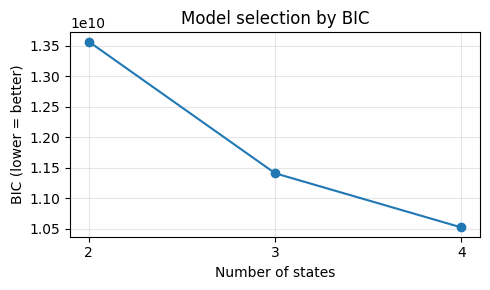

Selected n = 4 states


In [11]:
# BIC plot
ns   = list(results.keys())
bics = [results[n]['bic'] for n in ns]

plt.figure(figsize=(5, 3))
plt.plot(ns, bics, marker='o')
plt.xlabel('Number of states')
plt.ylabel('BIC (lower = better)')
plt.title('Model selection by BIC')
plt.xticks(ns)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n = min(results, key=lambda n: results[n]['bic'])
print(f'Selected n = {best_n} states')

## 3. Decode with Viterbi

In [12]:
best_model = results[best_n]['model']
df['hmm_state_raw'] = best_model.predict(X)   # integer state index

# Characterise each state by its mean features (in original scale)
state_means = pd.DataFrame(
    best_model.means_,
    columns=FEATURE_COLS
)
state_means.index.name = 'state'
# Un-standardise for readability
state_means_raw = state_means * scaler['stds'].values + scaler['means'].values
state_means_raw.columns = FEATURE_COLS
state_means_raw

,log_return,swap_count,total_fees_usd,realised_vol
state,,,,
0,0.000106,222.604224,4143.494111,16.091689
1,0.000069,157.482332,1381.450034,8.067270
2,0.000153,299.982479,10160.202568,32.111230
3,-0.001393,447.601200,23380.380561,80.518156


In [ ]:
# Post-hoc label assignment based on realised_vol ranking (low -> high)
vol_order = state_means_raw['realised_vol'].sort_values().index.tolist()

if best_n == 2:
    labels_by_vol = ['Low-vol', 'High-vol']
elif best_n == 3:
    labels_by_vol = ['Goldilocks', 'Trending', 'Toxic']
elif best_n == 4:
    labels_by_vol = ['Low-vol', 'Goldilocks', 'Trending', 'Toxic']
else:
    labels_by_vol = [f'State-{i}' for i in range(best_n)]

# rank -> label (kept for compatibility)
LABEL_MAP_BASE = {i: lbl for i, lbl in enumerate(labels_by_vol)}

# raw state index -> economic label
state_to_label = {raw_idx: labels_by_vol[i] for i, raw_idx in enumerate(vol_order)}
df['hmm_state'] = df['hmm_state_raw'].map(state_to_label)

print('State mapping (raw -> label):')
print(state_to_label)
print('\nHMM state counts:')
print(df['hmm_state'].value_counts(dropna=False))

KeyError: 3

## 4. Visualisations

In [ ]:
STATE_COLORS_HMM = {'Goldilocks': '#2ecc71', 'Trending': '#f39c12', 'Toxic': '#e74c3c',
                    'Low-vol': '#2ecc71', 'High-vol': '#e74c3c'}
hmm_label_order  = df['hmm_state'].unique().tolist()

# --- 4a. HMM regime timeline overlaid with fees ---
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(df['window'], df['total_fees_usd'], lw=0.6, color='steelblue', label='Fees (USD)')
axes[0].set_ylabel('Total fees (USD)')
axes[0].grid(alpha=0.3)

colors_hmm = df['hmm_state'].map(STATE_COLORS_HMM)
axes[1].bar(df['window'], np.ones(len(df)), width=1/24, color=colors_hmm, linewidth=0)
axes[1].set_yticks([])
patches = [mpatches.Patch(color=STATE_COLORS_HMM.get(s, 'grey'), label=s)
           for s in hmm_label_order]
axes[1].legend(handles=patches, loc='upper left', fontsize=8, ncol=best_n)

fig.suptitle(f'HMM regime labels (n={best_n}) — ETH/USDC 0.05%', fontsize=11)
plt.tight_layout()
plt.show()

KeyError: 'hmm_state'

In [ ]:
# --- 4b. Learned transition matrix ---
labels_ordered = [state_to_label[i] for i in sorted(state_to_label)]
trans_df = pd.DataFrame(
    best_model.transmat_,
    index=labels_ordered,
    columns=labels_ordered
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(trans_df, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title(f'HMM learned transition matrix (n={best_n})')
plt.tight_layout()
plt.show()

## 5. Compare HMM vs heuristic labels

In [ ]:
# Cross-tabulation (normalised by row = heuristic state)
if 'heuristic_state' in df.columns:
    ct = pd.crosstab(
        df['heuristic_state'],
        df['hmm_state'],
        normalize='index'
    ).round(3)
    print('Normalised cross-tab (rows = heuristic, cols = HMM):')
    display(ct)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title('HMM vs Heuristic state agreement')
    ax.set_xlabel('HMM state')
    ax.set_ylabel('Heuristic state')
    plt.tight_layout()
    plt.show()
else:
    print('heuristic_state column not found; run notebook 02 first.')

## 6. State-level summary

In [ ]:
summary = df.groupby('hmm_state')[FEATURE_COLS].agg(['mean', 'std']).round(4)
summary

In [ ]:
# Feature distributions per HMM state
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
hmm_states_sorted = sorted(df['hmm_state'].unique())
colors = [STATE_COLORS_HMM.get(s, 'grey') for s in hmm_states_sorted]

for ax, col in zip(axes, FEATURE_COLS):
    data = [df.loc[df['hmm_state'] == s, col].values for s in hmm_states_sorted]
    bp = ax.boxplot(data, labels=hmm_states_sorted, patch_artist=True, showfliers=False)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Feature distributions by HMM state (n={best_n})', fontsize=11)
plt.tight_layout()
plt.show()